## Dataset NYPD Shooting Incident Dataset

Description: Historical NYC shooting data, detailing incidents and outcomes (fatal or non-fatal).

Columns: Includes BORO, PERP_AGE_GROUP, VIC_AGE_GROUP, STATISTICAL_MURDER_FLAG, etc.

Purpose: Classify shootings as fatal or non-fatal to improve law enforcement strategies.

Applications: Crime analysis, predictive modeling, resource allocation.

Analysis Tasks: Data exploration, feature engineering, model building, and evaluation.

Relevance: Supports data-driven public safety measures and resource optimization.

## Step 1: Importing Libraries

In [1]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score,  confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
import geopandas as gpd
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

## Step 2: Loading the Dataset

In [163]:
df=pd.read_csv('NYPD_Shooting_Incident_Data__Historic_.csv')
df.head()

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,...,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,228798151,05/27/2021,21:30:00,QUEENS,NaN,105,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.058925e+06,180924.000000,40.662965,-73.730839,POINT (-73.73083868899994 40.662964620000025)
1,137471050,06/27/2014,17:40:00,BRONX,NaN,40,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.005028e+06,234516.000000,40.810352,-73.924942,POINT (-73.92494232599995 40.81035186300006)
2,147998800,11/21/2015,03:56:00,QUEENS,NaN,108,0.0,NaN,NaN,True,...,NaN,NaN,25-44,M,WHITE,1.007668e+06,209836.531250,40.742607,-73.915492,POINT (-73.91549174199997 40.74260663300004)
3,146837977,10/09/2015,18:30:00,BRONX,NaN,44,0.0,NaN,NaN,False,...,NaN,NaN,<18,M,WHITE HISPANIC,1.006537e+06,244511.140625,40.837782,-73.919457,POINT (-73.91945661499994 40.83778200300003)
4,58921844,02/19/2009,22:58:00,BRONX,NaN,47,0.0,NaN,NaN,True,...,M,BLACK,45-64,M,BLACK,1.024922e+06,262189.406250,40.886238,-73.852910,POINT (-73.85290950899997 40.88623791800006)


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27312 entries, 0 to 27311
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   INCIDENT_KEY             27312 non-null  int64  
 1   OCCUR_DATE               27312 non-null  object 
 2   OCCUR_TIME               27312 non-null  object 
 3   BORO                     27312 non-null  object 
 4   LOC_OF_OCCUR_DESC        1716 non-null   object 
 5   PRECINCT                 27312 non-null  int64  
 6   JURISDICTION_CODE        27310 non-null  float64
 7   LOC_CLASSFCTN_DESC       1716 non-null   object 
 8   LOCATION_DESC            12335 non-null  object 
 9   STATISTICAL_MURDER_FLAG  27312 non-null  bool   
 10  PERP_AGE_GROUP           17968 non-null  object 
 11  PERP_SEX                 18002 non-null  object 
 12  PERP_RACE                18002 non-null  object 
 13  VIC_AGE_GROUP            27312 non-null  object 
 14  VIC_SEX               

In [237]:
df.shape

(27312, 21)

In [165]:
df.columns.values

array(['INCIDENT_KEY', 'OCCUR_DATE', 'OCCUR_TIME', 'BORO',
       'LOC_OF_OCCUR_DESC', 'PRECINCT', 'JURISDICTION_CODE',
       'LOC_CLASSFCTN_DESC', 'LOCATION_DESC', 'STATISTICAL_MURDER_FLAG',
       'PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'VIC_AGE_GROUP',
       'VIC_SEX', 'VIC_RACE', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude',
       'Longitude', 'Lon_Lat'], dtype=object)

In [166]:
df.describe()

,INCIDENT_KEY,PRECINCT,JURISDICTION_CODE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,2.731200e+04,27312.000000,27310.000000,2.731200e+04,27312.000000,27302.000000,27302.000000
mean,1.208605e+08,65.635362,0.326913,1.009449e+06,208127.401608,40.737892,-73.909051
std,7.341286e+07,27.305705,0.737743,1.837783e+04,31886.377757,0.087525,0.066272
min,9.953245e+06,1.000000,0.000000,9.149281e+05,125756.718750,40.511586,-74.249303
25%,6.386088e+07,44.000000,0.000000,1.000029e+06,182834.335938,40.668481,-73.943027
50%,9.037222e+07,68.000000,0.000000,1.007731e+06,194486.570312,40.700318,-73.915221
75%,1.888102e+08,81.000000,0.000000,1.016838e+06,239518.468750,40.824067,-73.882330
max,2.611902e+08,123.000000,2.000000,1.066815e+06,271127.687500,40.910818,-73.702046


In [235]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
27307    False
27308    False
27309    False
27310    False
27311    False
Length: 27312, dtype: bool

In [167]:
df.isnull().sum()

INCIDENT_KEY                   0
OCCUR_DATE                     0
OCCUR_TIME                     0
BORO                           0
LOC_OF_OCCUR_DESC          25596
PRECINCT                       0
JURISDICTION_CODE              2
LOC_CLASSFCTN_DESC         25596
LOCATION_DESC              14977
STATISTICAL_MURDER_FLAG        0
PERP_AGE_GROUP              9344
PERP_SEX                    9310
PERP_RACE                   9310
VIC_AGE_GROUP                  0
VIC_SEX                        0
VIC_RACE                       0
X_COORD_CD                     0
Y_COORD_CD                     0
Latitude                      10
Longitude                     10
Lon_Lat                       10
dtype: int64

## Step 3: Data Preprocessing

In [168]:
# Remove rows with missing target variable values
df= df.dropna(subset=['STATISTICAL_MURDER_FLAG'])

In [169]:
# Fill missing values in other columns 
df.fillna(method='ffill', inplace=True)

In [170]:
# Encode categorical variables
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27312 entries, 0 to 27311
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   INCIDENT_KEY             27312 non-null  int64  
 1   OCCUR_DATE               27312 non-null  int32  
 2   OCCUR_TIME               27312 non-null  int32  
 3   BORO                     27312 non-null  int32  
 4   LOC_OF_OCCUR_DESC        27312 non-null  int32  
 5   PRECINCT                 27312 non-null  int64  
 6   JURISDICTION_CODE        27312 non-null  float64
 7   LOC_CLASSFCTN_DESC       27312 non-null  int32  
 8   LOCATION_DESC            27312 non-null  int32  
 9   STATISTICAL_MURDER_FLAG  27312 non-null  bool   
 10  PERP_AGE_GROUP           27312 non-null  int32  
 11  PERP_SEX                 27312 non-null  int32  
 12  PERP_RACE                27312 non-null  int32  
 13  VIC_AGE_GROUP            27312 non-null  int32  
 14  VIC_SEX               

In [172]:
# Check for class imbalance
print(df['STATISTICAL_MURDER_FLAG'].value_counts())

STATISTICAL_MURDER_FLAG
False    22046
True      5266
Name: count, dtype: int64


In [173]:
X = df.drop('STATISTICAL_MURDER_FLAG', axis=1)
y = df['STATISTICAL_MURDER_FLAG']

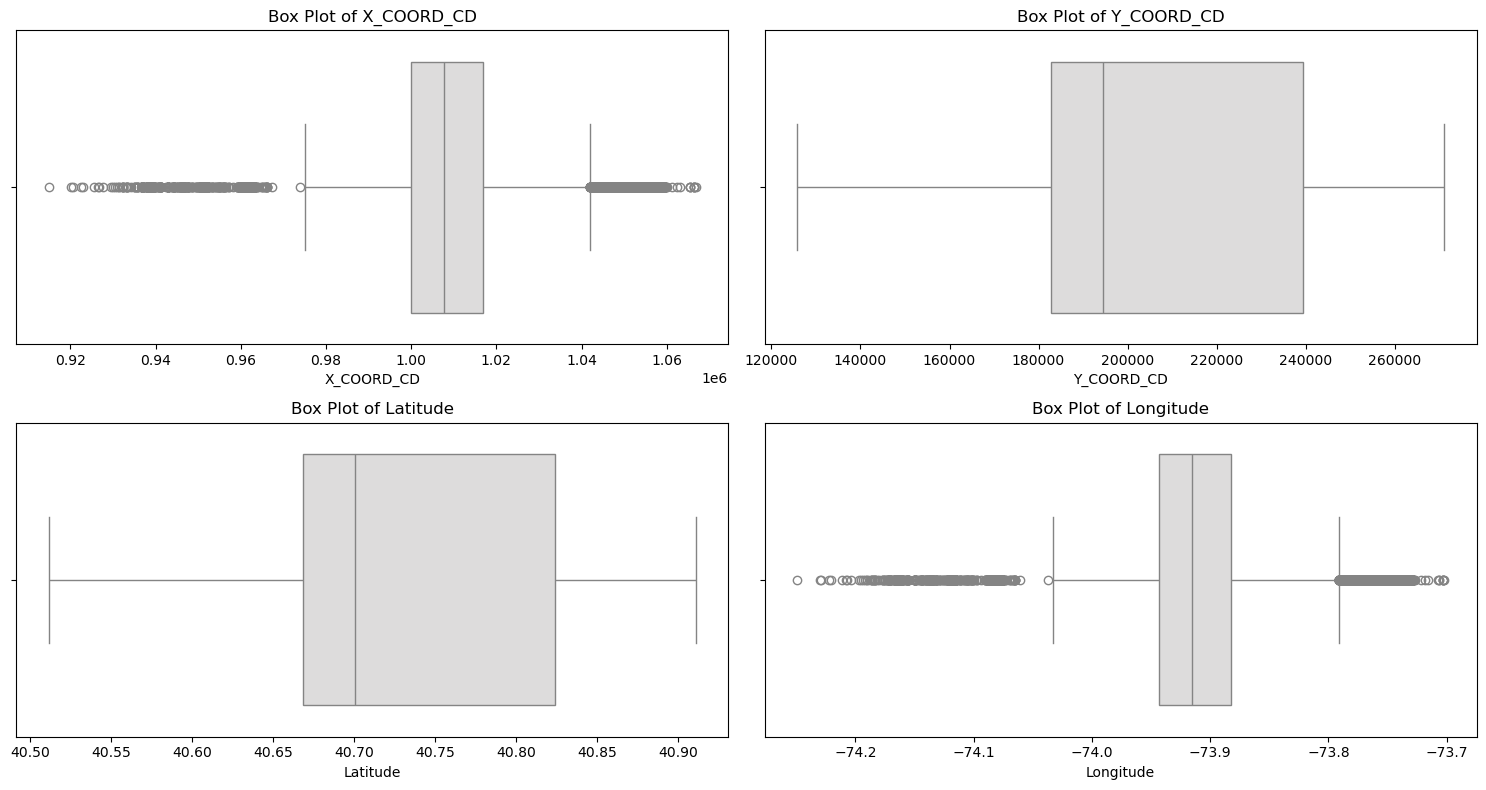

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of continuous columns
continuous_columns = ['X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude']  # Replace with relevant column names in your dataset

# Plot box plots for each continuous feature
plt.figure(figsize=(15, 8))
for i, column in enumerate(continuous_columns, 1):
    plt.subplot(2, 2, i)  # Adjust subplot layout if you have more or fewer columns
    sns.boxplot(data=df, x=column, palette='coolwarm')
    plt.title(f'Box Plot of {column}')
plt.tight_layout()
plt.show()


In [226]:
# Define function to cap outliers based on IQR
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

# Apply the function to relevant columns
for col in continuous_columns:  # List of continuous columns you want to treat
    cap_outliers(df, col)


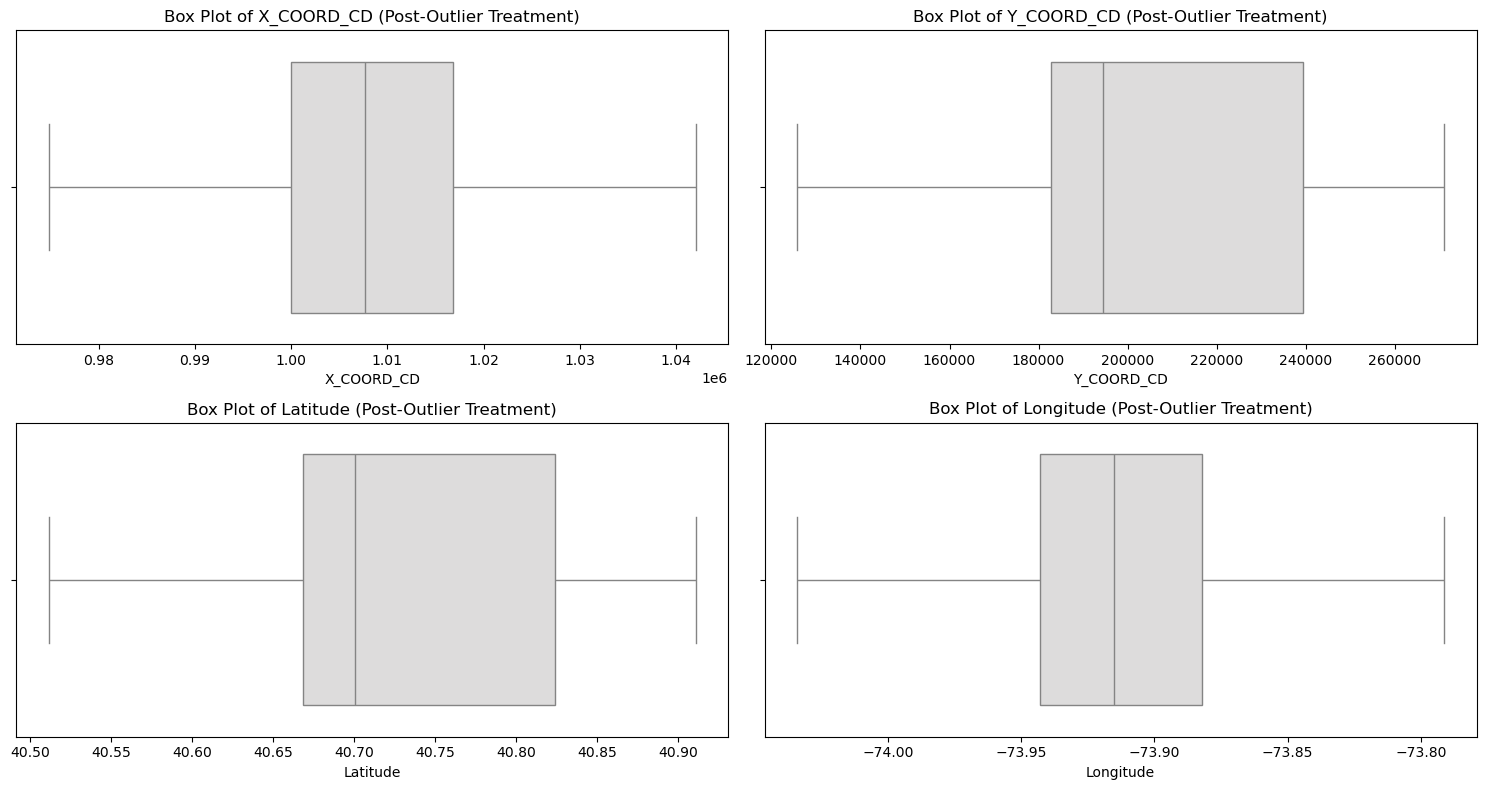

In [227]:
# Re-visualize box plots for continuous features after outlier treatment
plt.figure(figsize=(15, 8))
for i, column in enumerate(continuous_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=column, palette='coolwarm')
    plt.title(f'Box Plot of {column} (Post-Outlier Treatment)')
plt.tight_layout()
plt.show()


In [174]:
# Apply SMOTE to balance the classes in the target variable
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [175]:
# Scaling numerical features
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)

In [176]:
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X_res_scaled, y_res, test_size=0.3, random_state=42)

## Step 4: Exploratory Data Analysis


To understand patterns & potentially form some hypothesis

## 1. Distribution of STATISTICAL_MURDER_FLAG

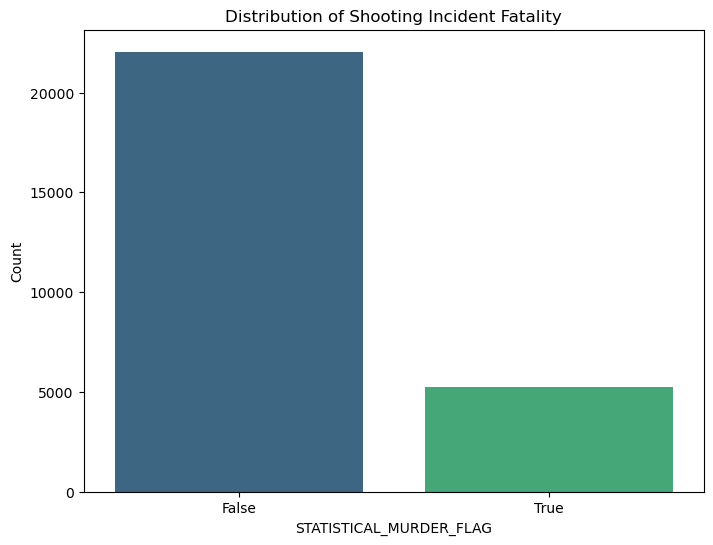

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='STATISTICAL_MURDER_FLAG', data=df, palette='viridis')
plt.title('Distribution of Shooting Incident Fatality')
plt.xlabel('STATISTICAL_MURDER_FLAG')
plt.ylabel('Count')
plt.show()



## 2. Distribution of incidents by borough

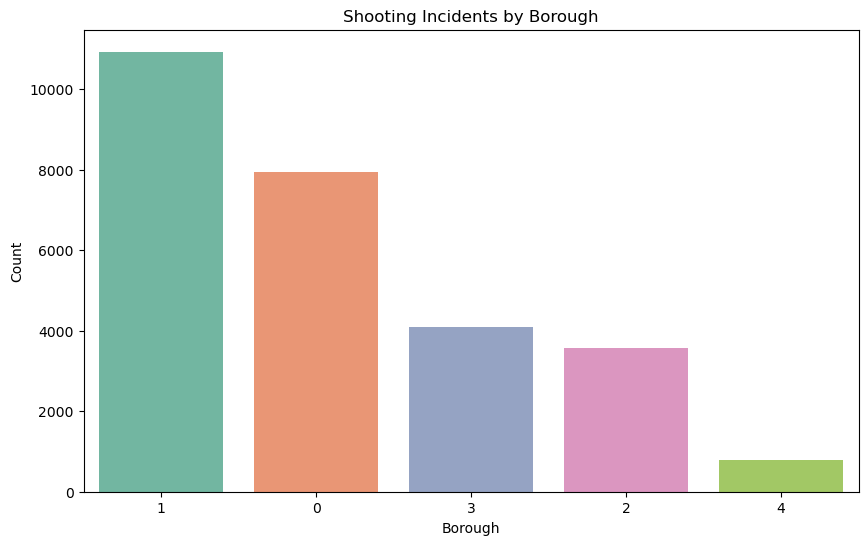

In [178]:
plt.figure(figsize=(10, 6))
sns.countplot(x='BORO', data=df, palette='Set2', order=df['BORO'].value_counts().index)
plt.title('Shooting Incidents by Borough')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.show()

## 3. Correlation heatmap

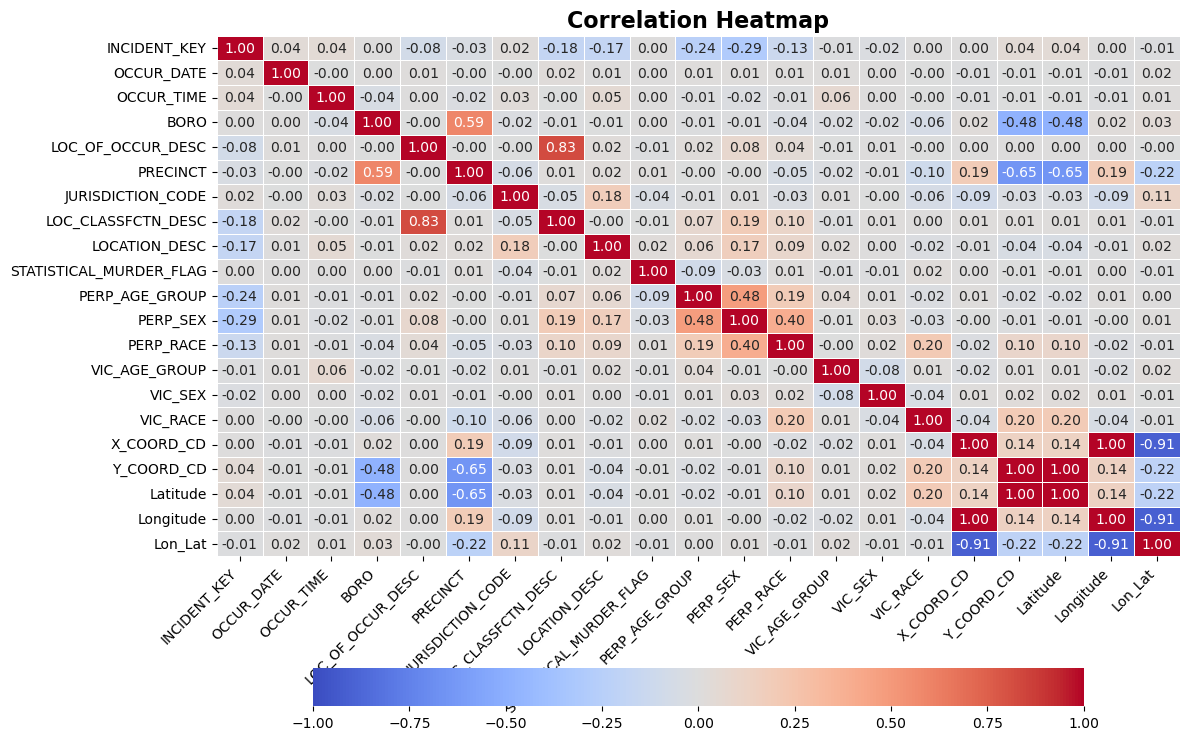

In [179]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Calculate correlation matrix
corr = df.corr()

# Create a heatmap with refined settings
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    annot_kws={"size": 10},  # Adjust font size of annotations
    linewidths=0.5,  # Add spacing between cells
    cbar_kws={"shrink": 0.8, "orientation": "horizontal"}  # Shrink color bar and move it below
)

plt.title('Correlation Heatmap', fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()  # Adjust layout to fit everything nicely
plt.show()


## 4. Distribution of shooting incidents by age group

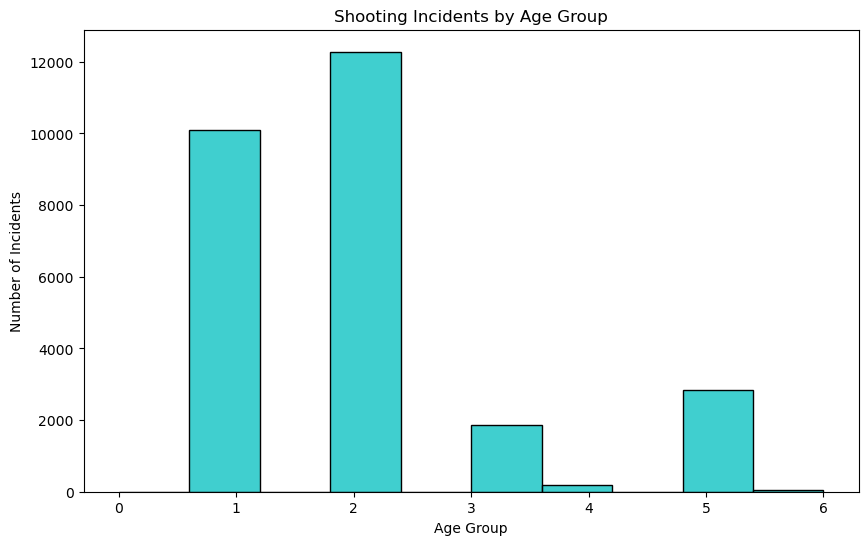

In [180]:
plt.figure(figsize=(10, 6))
sns.histplot(df['VIC_AGE_GROUP'], kde=False, color='c', bins=10)
plt.title('Shooting Incidents by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Incidents')
plt.show()

## 5. Distribution of Victim Gender

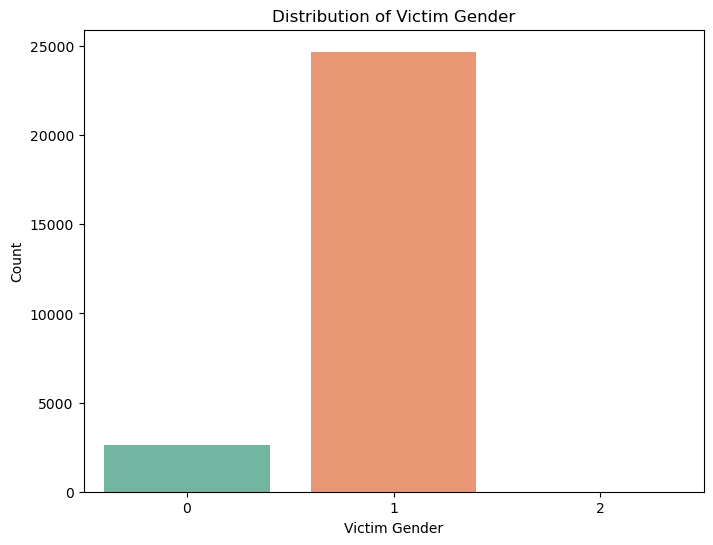

In [181]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='VIC_SEX', palette='Set2')
plt.title('Distribution of Victim Gender')
plt.xlabel('Victim Gender')
plt.ylabel('Count')
plt.show()

## 6. Geographical Distibution of Shooting Incidents

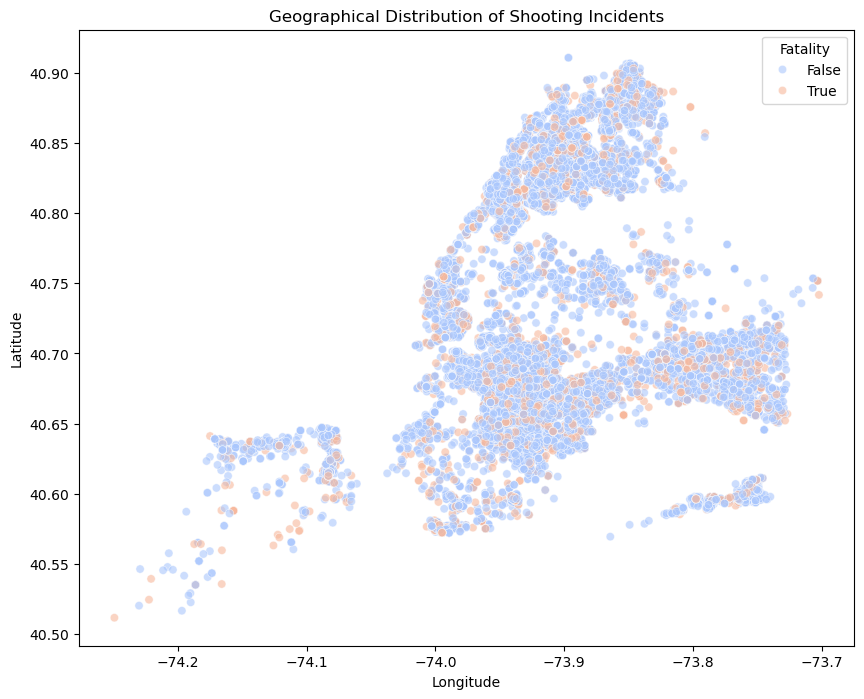

In [182]:
# Scatter plot of shooting incidents locations
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Longitude', y='Latitude', hue='STATISTICAL_MURDER_FLAG', data=df, palette='coolwarm', alpha=0.6)
plt.title('Geographical Distribution of Shooting Incidents')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Fatality')
plt.show()

## Step 5: Predictive Modeling-ML Algorithm
Developing

Random Forest,
Gradient Boosting
SVM
XGBoost
and compare them

## 1. Random Forest

In [183]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [184]:
print("Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(f"Precision: {precision_score(y_test, y_pred_rf)}")
print(f"Recall: {recall_score(y_test, y_pred_rf)}")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Performance:
Accuracy: 0.8408678560628969
Precision: 0.8754130865829478
Recall: 0.7968115506091141
[[5825  754]
 [1351 5298]]
              precision    recall  f1-score   support

       False       0.81      0.89      0.85      6579
        True       0.88      0.80      0.83      6649

    accuracy                           0.84     13228
   macro avg       0.84      0.84      0.84     13228
weighted avg       0.84      0.84      0.84     13228



## Hyperparameter Tuning for Random Forest

In [185]:
# Define the model
rf = RandomForestClassifier(random_state=42)

In [186]:
# Define the parameter grid
param_grid_rf = {
    'n_estimators': [50, 100],  # Number of trees in the forest
    'max_depth': [None, 10, 20],  # Maximum depth of the tree
    'min_samples_split': [2, 5],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2],  # Minimum number of samples required to be at a leaf node
}

In [187]:
# Set up GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=3, n_jobs=-1, verbose=1)

In [188]:
# Fit the model
grid_search_rf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             verbose=1)

In [189]:
# Best parameters
print("Best parameters for Random Forest:", grid_search_rf.best_params_)

Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [190]:
print(f"--- Random Forest ---")
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")

--- Random Forest ---
              precision    recall  f1-score   support

       False       0.81      0.89      0.85      6579
        True       0.88      0.80      0.83      6649

    accuracy                           0.84     13228
   macro avg       0.84      0.84      0.84     13228
weighted avg       0.84      0.84      0.84     13228

Accuracy: 0.8408678560628969


## 2. Gradient Boosting

In [191]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [192]:
print("Gradient Boosting Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb)}")
print(f"Precision: {precision_score(y_test, y_pred_gb)}")
print(f"Recall: {recall_score(y_test, y_pred_gb)}")
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Performance:
Accuracy: 0.7823556093135773
Precision: 0.8142714238079359
Recall: 0.7345465483531358
[[5465 1114]
 [1765 4884]]
              precision    recall  f1-score   support

       False       0.76      0.83      0.79      6579
        True       0.81      0.73      0.77      6649

    accuracy                           0.78     13228
   macro avg       0.79      0.78      0.78     13228
weighted avg       0.79      0.78      0.78     13228



## Hyperparameter Tuning for Gradient Boosting

In [193]:
# Define the model
gb = GradientBoostingClassifier(random_state=42)

In [194]:
# Define the parameter grid
param_grid_gb = {
    'n_estimators': [50, 100],  # Number of boosting stages
    'learning_rate': [0.01, 0.1],  # Learning rate
    'max_depth': [3, 5],  # Maximum depth of the individual estimators
    'min_samples_split': [2, 5],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2],  # Minimum number of samples required to be at a leaf node
}

In [195]:
# Set up GridSearchCV
grid_search_gb = GridSearchCV(estimator=gb, param_grid=param_grid_gb, cv=3, n_jobs=-1, verbose=1)

In [196]:
# Fit the model
grid_search_gb.fit(X_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             verbose=1)

In [197]:
# Best parameters
print("Best parameters for Gradient Boosting:", grid_search_gb.best_params_)

Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [198]:
print(f"--- Gradient Boosting ---")
print(classification_report(y_test, y_pred_gb))
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb)}")

--- Gradient Boosting ---
              precision    recall  f1-score   support

       False       0.76      0.83      0.79      6579
        True       0.81      0.73      0.77      6649

    accuracy                           0.78     13228
   macro avg       0.79      0.78      0.78     13228
weighted avg       0.79      0.78      0.78     13228

Accuracy: 0.7823556093135773


## 3. Support Vector Machine

In [199]:
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [200]:
print("SVM Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm)}")
print(f"Precision: {precision_score(y_test, y_pred_svm)}")
print(f"Recall: {recall_score(y_test, y_pred_svm)}")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Performance:
Accuracy: 0.7465225279709706
Precision: 0.785912560721721
Recall: 0.6813054594675891
[[5345 1234]
 [2119 4530]]
              precision    recall  f1-score   support

       False       0.72      0.81      0.76      6579
        True       0.79      0.68      0.73      6649

    accuracy                           0.75     13228
   macro avg       0.75      0.75      0.75     13228
weighted avg       0.75      0.75      0.75     13228



## Hyperparameter Tuning for SVM

In [201]:
# Define the model
svm = SVC(random_state=42)

In [202]:
# Define the parameter grid
param_grid_svm = {
    'C': [0.1, 1],  # Reduced values for regularization parameter
    'kernel': ['rbf'],  # Use only 'rbf' kernel for now
    'gamma': ['scale']  # Single value for gamma
}

In [203]:
# Set up GridSearchCV
grid_search_svm = GridSearchCV(estimator=svm, param_grid=param_grid_svm, cv=3, n_jobs=-1, verbose=1)

In [204]:
#Fit the model
grid_search_svm.fit(X_train, y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


GridSearchCV(cv=3, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1], 'gamma': ['scale'], 'kernel': ['rbf']},
             verbose=1)

In [205]:
# Best parameters
print("Best parameters for SVM:", grid_search_svm.best_params_)

Best parameters for SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [206]:
print(f"--- Support Vector Machine ---")
print(classification_report(y_test, y_pred_svm))
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm)}")

--- Support Vector Machine ---
              precision    recall  f1-score   support

       False       0.72      0.81      0.76      6579
        True       0.79      0.68      0.73      6649

    accuracy                           0.75     13228
   macro avg       0.75      0.75      0.75     13228
weighted avg       0.75      0.75      0.75     13228

Accuracy: 0.7465225279709706


## 4. XGBoost

In [207]:
from xgboost import XGBClassifier

In [208]:
# Initialize the XGBoost classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [209]:
# Fit the model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [210]:
# Make predictions
y_pred_xgb = xgb_model.predict(X_test)


In [211]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Confusion Matrix:
[[5960  619]
 [1574 5075]]

Classification Report:
              precision    recall  f1-score   support

       False       0.79      0.91      0.84      6579
        True       0.89      0.76      0.82      6649

    accuracy                           0.83     13228
   macro avg       0.84      0.83      0.83     13228
weighted avg       0.84      0.83      0.83     13228



## Hyperparameter Tuning for XGBoost

In [212]:
# Define the parameter grid for tuning
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0]
}

In [213]:
# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, 
                           scoring='accuracy', cv=3, verbose=1, n_jobs=-1)

In [214]:
# Fit GridSearchCV
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 81 candidates, totalling 243 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 150],
                         'subsample': [0.6, 0.8, 1.0]},
             scoring='accuracy', verbose=1)

In [215]:
# Best parameters and best score
print("Best Parameters: ", grid_search.best_params_)
print("Best Cross-Validation Score: ", grid_search.best_score_)

Best Parameters:  {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 150, 'subsample': 1.0}
Best Cross-Validation Score:  0.8412713841368585


In [216]:
# Make predictions with the best model
best_model = grid_search.best_estimator_
y_pred_xgb = best_model.predict(X_test)

In [217]:
# Evaluate the best model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Confusion Matrix:
[[5969  610]
 [1480 5169]]

Classification Report:
              precision    recall  f1-score   support

       False       0.80      0.91      0.85      6579
        True       0.89      0.78      0.83      6649

    accuracy                           0.84     13228
   macro avg       0.85      0.84      0.84     13228
weighted avg       0.85      0.84      0.84     13228



## Step 6: Model Comparison

In [218]:
# Model Performance Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score

models = ['Random Forest', 'Gradient Boosting', 'SVM','XGBoost']
accuracy = [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_gb), accuracy_score(y_test, y_pred_svm),accuracy_score(y_test, y_pred_xgb)]
precision = [precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_gb), precision_score(y_test, y_pred_svm),precision_score(y_test, y_pred_xgb)]
recall = [recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_gb), recall_score(y_test, y_pred_svm),recall_score(y_test, y_pred_xgb)]

In [219]:
# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall
})

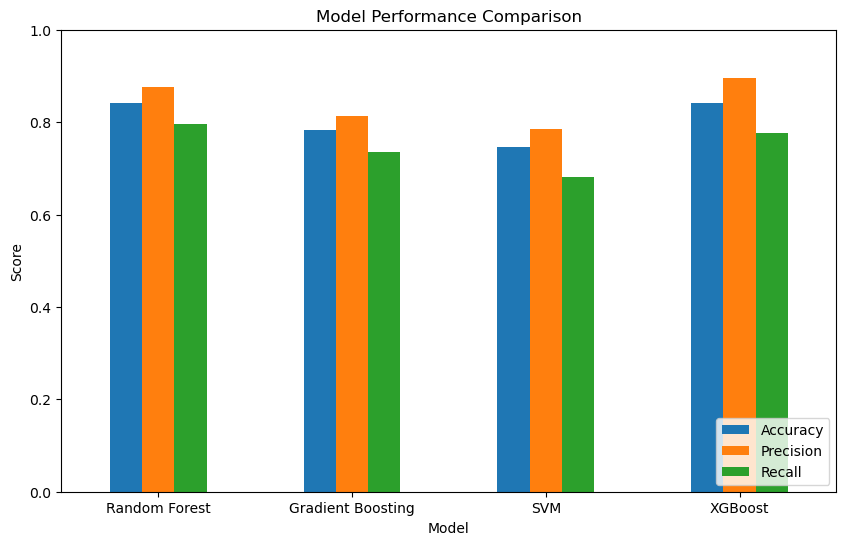

In [220]:
# Plotting the Comparison
comparison_df.set_index('Model', inplace=True)
comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

##  Applying SMOTE Only on Training Data

In [221]:
from sklearn.model_selection import train_test_split

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(X, y, test_size=0.3, random_state=42)


In [222]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote_res, y_train_smote_res = smote.fit_resample(X_train_smote, y_train_smote)


In [224]:
from sklearn.ensemble import RandomForestClassifier

# Define the model (e.g., Random Forest)
model_orig = RandomForestClassifier(random_state=42)
model_smote = RandomForestClassifier(random_state=42)  # Define the same model for consistency

# Train and evaluate on the original dataset
print("Original Dataset Results:")
model_orig.fit(X_train_orig, y_train_orig)
y_pred_orig = model_orig.predict(X_test_orig)
evaluate_model(y_test_orig, y_pred_orig)

# Train and evaluate on the SMOTE-enhanced dataset
print("\nSMOTE Dataset Results:")
model_smote.fit(X_train_smote_res, y_train_smote_res)
y_pred_smote = model_smote.predict(X_test_smote)
evaluate_model(y_test_smote, y_pred_smote)


Original Dataset Results:
Accuracy: 0.787283378081523
Precision: 0.2675
Recall: 0.06872190109184328
F1 Score: 0.10935104752171691

SMOTE Dataset Results:
Accuracy: 0.7610446668293873
Precision: 0.28556149732620323
Recall: 0.17148362235067438
F1 Score: 0.21428571428571427


## Choosing the best model

In [233]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import xgboost as xgb
import joblib

# Function to evaluate model and print performance metrics
def evaluate_model(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")
    return f1

# Split the data for original and SMOTE-enhanced datasets
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X, y, test_size=0.3, random_state=42)
smote = SMOTE(random_state=42)
X_train_smote_res, y_train_smote_res = smote.fit_resample(X_train_orig, y_train_orig)

# Define models for evaluation
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Evaluate models on both original and SMOTE datasets, selecting the best
best_f1_score = 0
best_model = None

print("Evaluating models on the Original Dataset:")
for name, model in models.items():
    model.fit(X_train_orig, y_train_orig)
    y_pred_orig = model.predict(X_test_orig)
    print(f"{name} - Original Dataset")
    f1_orig = evaluate_model(y_test_orig, y_pred_orig)
    if f1_orig > best_f1_score:
        best_f1_score = f1_orig
        best_model = model

print("\nEvaluating models on the SMOTE Dataset:")
for name, model in models.items():
    model.fit(X_train_smote_res, y_train_smote_res)
    y_pred_smote = model.predict(X_test_orig)  # Evaluate on the original test set
    print(f"{name} - SMOTE Dataset")
    f1_smote = evaluate_model(y_test_orig, y_pred_smote)
    if f1_smote > best_f1_score:
        best_f1_score = f1_smote
        best_model = model

# Save the best model
joblib.dump(best_model, 'best_model.pkl')
print("\nBest model selected for deployment:", best_model)


Evaluating models on the Original Dataset:
Random Forest - Original Dataset
Accuracy: 0.7870, Precision: 0.2650, Recall: 0.0681, F1 Score: 0.1083
Gradient Boosting - Original Dataset
Accuracy: 0.8102, Precision: 0.6000, Recall: 0.0039, F1 Score: 0.0077
SVM - Original Dataset
Accuracy: 0.8100, Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000
XGBoost - Original Dataset
Accuracy: 0.7981, Precision: 0.3610, Recall: 0.0809, F1 Score: 0.1322

Evaluating models on the SMOTE Dataset:
Random Forest - SMOTE Dataset
Accuracy: 0.7606, Precision: 0.2906, Recall: 0.1805, F1 Score: 0.2227
Gradient Boosting - SMOTE Dataset
Accuracy: 0.7294, Precision: 0.2708, Recall: 0.2505, F1 Score: 0.2603
SVM - SMOTE Dataset
Accuracy: 0.5168, Precision: 0.1975, Recall: 0.5035, F1 Score: 0.2837
XGBoost - SMOTE Dataset
Accuracy: 0.7746, Precision: 0.3210, Recall: 0.1670, F1 Score: 0.2197

Best model selected for deployment: SVC(probability=True, random_state=42)
